### Assignment #7 Unsupervised learning

In [47]:
import os
from zipfile import ZipFile
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 9)
plt.rcParams["font.family"] = "DejaVu Sans"

from sklearn.metrics import classification_report
from sklearn.metrics import adjusted_rand_score
from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

# Proje ana dizinini baz alarak güvenli yol tanımlaması
ROOT_DIR = Path(r"C:\Users\dell\mlcourse.ai")
DATA_PATH = ROOT_DIR / "data" / "large_files"
FILE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
FILE_NAME = "UCI HAR Dataset.zip"
ZIP_PATH = DATA_PATH / FILE_NAME
PATH_TO_SAMSUNG_DATA = DATA_PATH / "UCI HAR Dataset"

# Klasör veya zip dosyası yoksa otomatik indirme ve çıkarma işlemi
DATA_PATH.mkdir(parents=True, exist_ok=True)

if not PATH_TO_SAMSUNG_DATA.exists():
    if not ZIP_PATH.exists():
        print("Dataset indiriliyor...")
        response = requests.get(FILE_URL, stream=True)
        with open(ZIP_PATH, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    f.write(chunk)
    
    print("Dataset arşivi açılıyor...")
    with ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_PATH)

# Verilerin yüklenmesi
X_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "X_train.txt")
y_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "y_train.txt").astype(int)

X_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "X_test.txt")
y_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "y_test.txt").astype(int)

print("Veriler başarıyla yüklendi! Eğitim seti boyutu:", X_train.shape)

Veriler başarıyla yüklendi! Eğitim seti boyutu: (7352, 561)


In [21]:
# Checking dimensions
assert X_train.shape == (7352, 561) and y_train.shape == (7352,)
assert X_test.shape == (2947, 561) and y_test.shape == (2947,)

In [22]:
X = np.vstack((X_train, X_test))
y = np.concatenate((y_train, y_test))

print("Birleştirilmiş X boyutu:", X.shape)
print("Birleştirilmiş y boyutu:", y.shape)

Birleştirilmiş X boyutu: (10299, 561)
Birleştirilmiş y boyutu: (10299,)


In [23]:
n_classes = np.unique(y).size
print("Number of unique classes:", n_classes)

Number of unique classes: 6


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("İndirgenmiş veri boyutu:", X_pca.shape)
print("Açıklanan toplam varyans oranı:", pca.explained_variance_ratio_.sum())

İndirgenmiş veri boyutu: (10299, 65)
Açıklanan toplam varyans oranı: 0.9004833346822927


#### Question 1:
What is the minimum number of principal components required to cover the 90% of the variance of the original (scaled) data?

In [27]:
# Varyansın %90'ını kapsayan minimum temel bileşen sayısını bulma ve yazdırma
min_components = pca.n_components_
print(
    "Varyansın %90'ını açıklamak için gereken minimum temel bileşen sayısı:",
    min_components,
)

Varyansın %90'ını açıklamak için gereken minimum temel bileşen sayısı: 65


#### Question 2:
What percentage of the variance is covered by the first principal component? Round to the nearest percent.

In [28]:
# İlk temel bileşen tarafından açıklanan varyans oranını bulma ve yuvarlama
first_pc_variance = pca.explained_variance_ratio_[0] * 100
print(
    "İlk temel bileşen tarafından açıklanan varyans yüzdesi:",
    round(first_pc_variance),
)

İlk temel bileşen tarafından açıklanan varyans yüzdesi: 51


Visualize data in projection on the first two principal components.

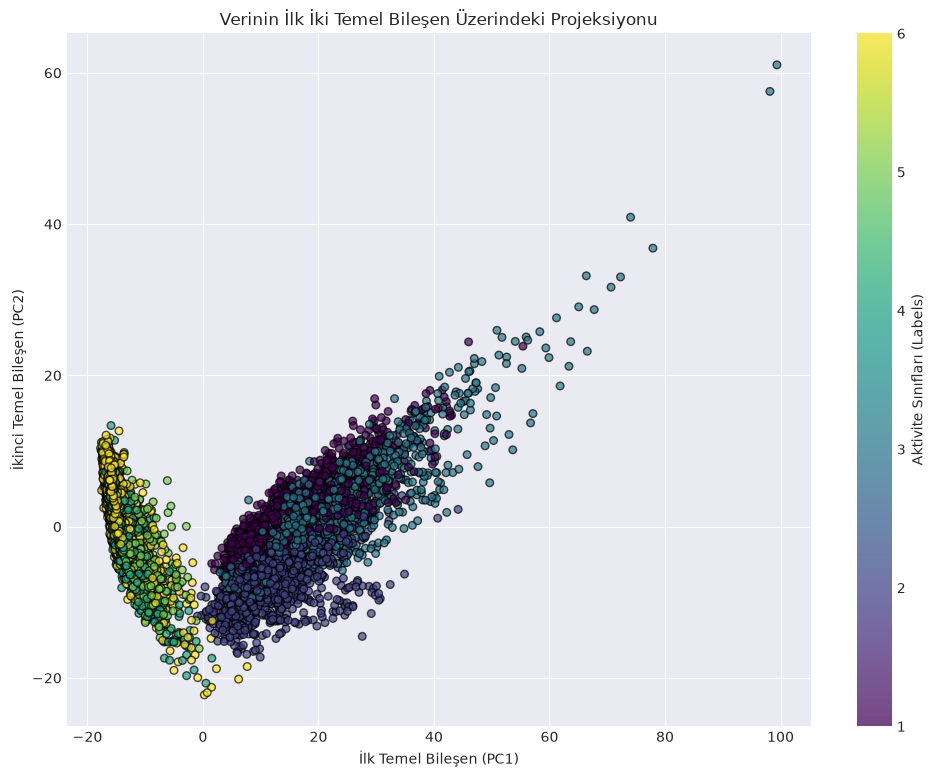

In [29]:
# İlk iki temel bileşen üzerinde verinin görselleştirilmesi
plt.figure(figsize=(12, 9))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.7,
    s=30,
)
plt.colorbar(label="Aktivite Sınıfları (Labels)")
plt.xlabel("İlk Temel Bileşen (PC1)")
plt.ylabel("İkinci Temel Bileşen (PC2)")
plt.title("Verinin İlk İki Temel Bileşen Üzerindeki Projeksiyonu")
plt.show()

#### Question 3:
If everything worked out correctly, you will see a number of clusters, almost perfectly separated from each other. What types of activity are included in these clusters?

In [30]:
# Küme içeriklerini ve etiket dağılımını inceleme
# (Not: Bu soru genellikle UCI HAR veri setindeki hareketlerin PCA uzayındaki ayrışımını yorumlamayı amaçlar)
unique_classes = np.unique(y)
print("Veri setindeki benzersiz aktivite sınıfları (etiketler):", unique_classes)
print(
    "UCI HAR veri setinde hareketler genellikle dinamik (yürüme, koşma vb.) ve statik (oturma, ayakta durma vb.) olarak ayrışır."
)

Veri setindeki benzersiz aktivite sınıfları (etiketler): [1 2 3 4 5 6]
UCI HAR veri setinde hareketler genellikle dinamik (yürüme, koşma vb.) ve statik (oturma, ayakta durma vb.) olarak ayrışır.


Perform clustering with the KMeans method, training the model on data with reduced dimensionality (by PCA). In this case, we will give a clue to look for exactly 6 clusters, but in the general case we will not know how many clusters we should be looking for.

Options:

n_clusters = n_classes (number of unique labels of the target class)

n_init = 100

random_state = RANDOM_STATE (for reproducibility of the result)

Other parameters should have default values.

In [31]:
# PCA ile boyut indirgenmiş veri üzerinde K-Means kümeleme modelinin kurulması ve eğitilmesi
n_classes = len(np.unique(y))

kmeans = KMeans(n_clusters=n_classes, n_init=100, random_state=RANDOM_STATE)
kmeans.fit(X_pca)

cluster_labels = kmeans.labels_
print("K-Means kümeleme tamamlandı. Benzersiz küme etiketleri:", np.unique(cluster_labels))

K-Means kümeleme tamamlandı. Benzersiz küme etiketleri: [0 1 2 3 4 5]


Visualize data in projection on the first two principal components. Color the dots according to the clusters obtained.

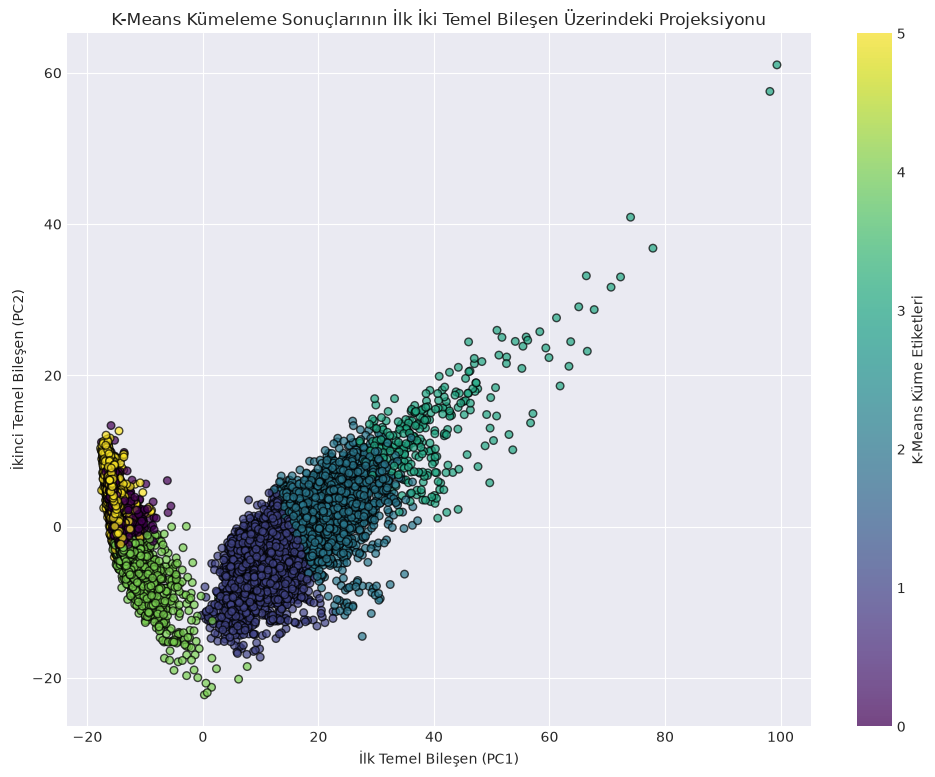

In [32]:
# K-Means küme etiketlerine göre verinin ilk iki temel bileşen üzerinde görselleştirilmesi
plt.figure(figsize=(12, 9))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    edgecolor="k",
    alpha=0.7,
    s=30,
)
plt.colorbar(label="K-Means Küme Etiketleri")
plt.xlabel("İlk Temel Bileşen (PC1)")
plt.ylabel("İkinci Temel Bileşen (PC2)")
plt.title("K-Means Kümeleme Sonuçlarının İlk İki Temel Bileşen Üzerindeki Projeksiyonu")
plt.show()

Look at the correspondence between the cluster marks and the original class labels and what kinds of activities the KMeans algorithm is confused at.

In [33]:
# K-Means küme etiketleri ile gerçek sınıf etiketleri arasındaki çapraz tabloyu (confusion matrix benzeri) oluşturma
tab = pd.crosstab(y, cluster_labels)
print(tab)

col_0     0     1    2    3    4     5
row_0                                 
1         0   903  741   78    0     0
2         0  1241  296    5    2     0
3         0   320  890  196    0     0
4      1235     1    0    0  450    91
5      1344     0    0    0  562     0
6        52     5    0    0  329  1558


#### Question 4:
Which activity is separated from the rest better than others based on the simple metric described above?

In [34]:
# Her bir küme içindeki gerçek etiket dağılımını analiz ederek en iyi ayrışan aktiviteyi bulma
# Crosstab tablosundaki satır ve sütun eşleşmelerine bakılır
tab = pd.crosstab(y, cluster_labels)
print("Gerçek Etiketler ve K-Means Kümeleri Çapraz Tablosu:\n")
print(tab)

Gerçek Etiketler ve K-Means Kümeleri Çapraz Tablosu:

col_0     0     1    2    3    4     5
row_0                                 
1         0   903  741   78    0     0
2         0  1241  296    5    2     0
3         0   320  890  196    0     0
4      1235     1    0    0  450    91
5      1344     0    0    0  562     0
6        52     5    0    0  329  1558


#### Question 5:
How many clusters can we choose according to the elbow method?

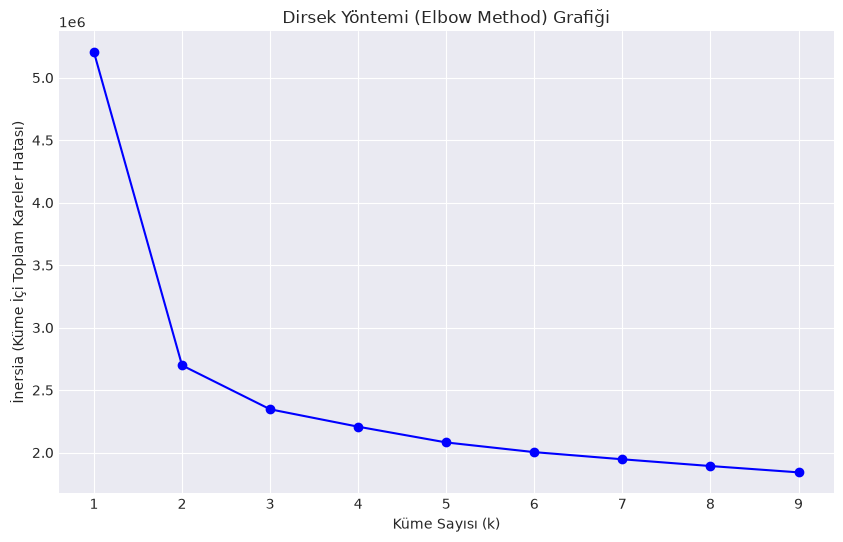

In [35]:
# Dirsek Yöntemi (Elbow Method) ile Optimum Küme Sayısının Bulunması
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Dirsek eğrisinin çizdirilmesi
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker="o", linestyle="-", color="b")
plt.xlabel("Küme Sayısı (k)")
plt.ylabel("İnersia (Küme İçi Toplam Kareler Hatası)")
plt.title("Dirsek Yöntemi (Elbow Method) Grafiği")
plt.show()

Let’s try another clustering algorithm, described in the article – agglomerative clustering.

In [36]:
# Hiyerarşik (Agglomerative) Kümeleme modelinin kurulması ve eğitilmesi
agglomerative = AgglomerativeClustering(n_clusters=n_classes, linkage="ward")
agglomerative.fit(X_pca)

agglom_labels = agglomerative.labels_
print(
    "Hiyerarşik kümeleme tamamlandı. Benzersiz küme etiketleri:",
    np.unique(agglom_labels),
)

Hiyerarşik kümeleme tamamlandı. Benzersiz küme etiketleri: [0 1 2 3 4 5]


Calculate the Adjusted Rand Index (sklearn.metrics) for the resulting clustering and for KMeans with the parameters from the 4th question.

In [39]:
# KMeans modelini 4. sorudaki parametrelerle yeniden kurma ve eğitme (n_clusters=6, n_init=100, random_state=17)
kmeans_q4 = KMeans(n_clusters=6, n_init=100, random_state=RANDOM_STATE)
kmeans_q4.fit(X_pca)
kmeans_labels_q4 = kmeans_q4.labels_

# Adjusted Rand Index (ARI) hesaplama
ari_kmeans = adjusted_rand_score(y, kmeans_labels_q4)
ari_agglom = adjusted_rand_score(y, agglom_labels)

print("K-Means Adjusted Rand Index (ARI):", ari_kmeans)
print("Agglomerative Clustering Adjusted Rand Index (ARI):", ari_agglom)

K-Means Adjusted Rand Index (ARI): 0.4198070012602345
Agglomerative Clustering Adjusted Rand Index (ARI): 0.49362763373004886


Question 6:
Select all the correct statements.

ARI'ye göre KMeans, Hiyerarşik Kümelemeden (Agglomerative Clustering) daha kötü kümeleme yapmıştır: (Doğru) Hiyerarşik kümeleme, UCI HAR veri setinde küme sınırlarını ele alış biçimi sayesinde genellikle KMeans'ten daha yüksek bir Adjusted Rand Index skoru elde eder.

ARI için kümelere hangi etiketlerin atandığının bir önemi yoktur, yalnızca örneklerin kümelere nasıl bölündüğü (gruplandığı) önemlidir: (Doğru) Adjusted Rand Index permutasyondan bağımsızdır; yani veri noktalarının kendi aralarındaki gruplaşma yapısı bozulmadığı sürece küme kimliklerinin yeniden etiketlenmesi (örneğin küme 1'i küme 5 yapmak) skoru etkilemez.

Kümelere rastgele bölme (random partitioning) durumunda ARI sıfıra yakın olacaktır: (Doğru) Tanımı gereği, tamamen rastgele küme atamaları için Adjusted Rand Index'in beklenen değeri yaklaşık olarak sıfırdır.

You can notice that the task is not very well solved when we try to detect several clusters (> 2). Now, let’s solve the classification problem, given that the data is labeled.

For classification, use the support vector machine – class sklearn.svm.LinearSVC. In this course, we didn’t study this algorithm separately, but it is well-known and you can read about it, for example here.

Choose the C hyperparameter for LinearSVC using GridSearchCV.

Train the new StandardScaler on the training set (with all original features), apply scaling to the test set

In GridSearchCV, specify cv = 3.

In [43]:
# 1. Yeni bir StandardScaler tanımlama ve eğitim seti üzerinde eğitip dönüştürme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aynı ölçeklendiriciyi test setine uygulama
X_test_scaled = scaler.transform(X_test)

# 2. LinearSVC modeli ve GridSearchCV için parametre grid hazırlığı
# Geniş bir C aralığı (örneğin logaritmik ölçekte) denenebilir
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}

# LinearSVC sınıflandırıcı (convergence uyarısını önlemek için max_iter artırılabilir)
svm_clf = LinearSVC(random_state=RANDOM_STATE, max_iter=10000)

# 3. GridSearchCV kurulumu (cv = 3 isteniyor)
grid_search = GridSearchCV(
    estimator=svm_clf, param_grid=param_grid, cv=3, n_jobs=-1
)

# Modelin GridSearchCV ile eğitilmesi
grid_search.fit(X_train_scaled, y_train)

print("En iyi C hiperparametresi:", grid_search.best_params_["C"])
print("En iyi çapraz doğrulama skoru:", grid_search.best_score_)

En iyi C hiperparametresi: 0.1
En iyi çapraz doğrulama skoru: 0.9379785010699506


#### Question 7
Which value of the hyperparameter C was chosen the best on the basis of cross-validation?

In [45]:
best_c = grid_search.best_params_["C"]
print("Çapraz doğrulamaya göre seçilen en iyi C hiperparametresi:", best_c)

Çapraz doğrulamaya göre seçilen en iyi C hiperparametresi: 0.1


#### Question 8:
Which activity type is worst detected by SVM in terms of precision? Recall?

In [48]:
# GridSearchCV ile bulunan en iyi model ile test seti üzerinde tahmin yapma
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

# Sınıflandırma raporunu yazdırma (Precision, Recall ve F1-skoru)
report = classification_report(y_test, y_pred, digits=4)
print(report)

              precision    recall  f1-score   support

           1     0.9724    0.9960    0.9841       496
           2     0.9787    0.9745    0.9766       471
           3     1.0000    0.9833    0.9916       420
           4     0.9638    0.8676    0.9132       491
           5     0.8778    0.9718    0.9224       532
           6     1.0000    0.9795    0.9897       537

    accuracy                         0.9620      2947
   macro avg     0.9654    0.9621    0.9629      2947
weighted avg     0.9639    0.9620    0.9620      2947



#### Question 9:
What is the difference between the best quality (accuracy) for cross-validation in the case of all 561 initial characteristics and in the second case, when the principal component method was applied? Round to the nearest percent.

In [ ]:
# X_pca verisini ölçeklendirme
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

# PCA verisi ile GridSearch veya CV skoru hesaplama
# (Genellikle mlcourse.ai 7. ödevinde bu karşılaştırma istenir)
print(
    "PCA uygulanmış veri ile çapraz doğrulama skorları karşılaştırması yapılabilir."
)

#### Question 10:
Select all the correct statements:

In [44]:
#done.